In [2]:
import random
random.seed(42)

In [3]:
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm
from torch.nn.utils.parametrize import remove_parametrizations

In [4]:
import os
import pandas as pd
import numpy as np
import shutil
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from optuna.importance import get_param_importances
from optuna.importance import MeanDecreaseImpurityImportanceEvaluator
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

import lightgbm as lgb
import optuna

In [5]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [6]:
pd.set_option('display.max_columns', None)

# TCN

In [7]:
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = dilation * (kernel_size - 1)
        self.conv = weight_norm(nn.Conv1d(in_channels, out_channels, kernel_size, padding=self.padding, dilation=dilation))

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, dropout=0.2):
        super(ResidualBlock, self).__init__()
        
        self.optional_conv = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

        self.causal_conv1 = CausalConv1d(in_channels, out_channels, kernel_size, dilation)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout)

        self.causal_conv2 = CausalConv1d(out_channels, out_channels, kernel_size, dilation)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout)

        self.residual = nn.Sequential(self.causal_conv1, self.relu1, self.dropout1, 
                                      self.causal_conv2, self.relu2, self.dropout2)

        # self.relu = nn.ReLU()

    def forward(self, x):
        res = self.residual(x)
        x_conv = self.optional_conv(x) if self.optional_conv is not None else x
        # out = self.relu(x_conv + res)
        out = x_conv + res
        return out

In [9]:
class TCN(nn.Module):
    def __init__(self, in_channels, out_channels, levels, kernel_size, dropout=0.2):
        super(TCN, self).__init__()
        layers = []
        for i in range(levels):
            dilation = 2 ** i
            now_num_channels = in_channels if i == 0 else out_channels[i - 1]
            now_out_channels = out_channels[i]
            layers += [ResidualBlock(now_num_channels, now_out_channels, kernel_size, dilation, dropout)]

        self.tcn = nn.Sequential(*layers)
        self.linear = nn.Linear(out_channels[-1], 1)

    def forward(self, x, return_embeddings=False):
        x = self.tcn(x)
        if return_embeddings:            
            return x
        x = x.transpose(1, 2) 
        x = self.linear(x)
        return x

# Dataset processing

In [10]:
df_full=pd.read_csv('/kaggle/input/processed-sepsis-dataset/processed_dataset_v2.psv', sep="|")
importance_df_wo_windows=pd.read_csv('/kaggle/input/datasets/annarechkalova/tcn-importance-wo-windows/importance_df_wo_windows_tcn.csv')
top_features_wo_windows = importance_df_wo_windows[importance_df_wo_windows['Importance'] > 0]
df_col = ['id', 'SepsisLabel']
df_col += top_features_wo_windows['Feature'].tolist()
df = df_full[df_col]

In [53]:
df

,id,SepsisLabel,ICULOS,Temp,WBC,EtCO2_missing,DBP,FiO2_missing,SBP_missing,HR,MAP_missing,Platelets,BUN,FiO2,pH,Creatinine,ShockIndex,Potassium,O2Sat,pH_missing,Bilirubin_total,Hct,Lactate,Glucose,Resp_missing,Chloride,PaCO2_missing,Temp_missing,Lactate_missing,Hgb,Gender,SaO2_missing,Unit2,DBP_missing,Resp,HR_missing,Phosphate,AST_missing,Unit1,Calcium,O2Sat_missing,AST,Chloride_missing,Alkalinephos_missing,BaseExcess_missing,TroponinI_missing,PTT,Calcium_missing,SBP,Bilirubin_total_missing,BUN_missing,Hgb_missing,MAP,Fibrinogen_missing,HCO3_missing,WBC_missing
0,p000001,0,1,NaN,NaN,1,NaN,1,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,1,NaN,1,1,1,NaN,0,1,NaN,1,NaN,1,NaN,1,NaN,NaN,1,NaN,1,1,1,1,NaN,1,NaN,1,1,1,NaN,1,1,1
1,p000001,0,2,NaN,NaN,1,NaN,1,0,97.0,0,NaN,NaN,NaN,NaN,NaN,0.989796,NaN,95.0,1,NaN,NaN,NaN,NaN,0,NaN,1,1,1,NaN,0,1,NaN,1,19.0,0,NaN,1,NaN,NaN,0,NaN,1,1,1,1,NaN,1,98.0,1,1,1,75.33,1,1,1
2,p000001,0,3,NaN,NaN,1,NaN,1,0,89.0,0,NaN,NaN,NaN,NaN,NaN,0.729508,NaN,99.0,1,NaN,NaN,NaN,NaN,0,NaN,1,1,1,NaN,0,1,NaN,1,22.0,0,NaN,1,NaN,NaN,0,NaN,1,1,1,1,NaN,1,122.0,1,1,1,86.00,1,1,1
3,p000001,0,4,NaN,NaN,1,NaN,1,1,90.0,1,NaN,NaN,NaN,7.36,NaN,0.737705,NaN,95.0,0,NaN,NaN,NaN,NaN,0,NaN,0,1,1,NaN,0,1,NaN,1,30.0,0,NaN,1,NaN,NaN,0,NaN,1,1,0,1,NaN,1,122.0,1,1,1,86.00,1,1,1
4,p000001,0,5,NaN,NaN,1,NaN,0,0,103.0,0,NaN,NaN,0.28,7.36,NaN,0.844262,NaN,88.5,1,NaN,NaN,NaN,NaN,0,NaN,1,1,1,NaN,0,1,NaN,1,24.5,0,NaN,1,NaN,NaN,0,NaN,1,1,1,1,NaN,1,122.0,1,1,1,91.33,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,p120000,0,31,36.4,5.4,1,65.0,1,0,80.0,0,216.0,11.0,NaN,NaN,0.54,0.695652,3.6,96.0,1,0.9,37.1,NaN,239.0,0,NaN,1,1,1,11.6,0,1,NaN,0,15.0,0,4.0,1,NaN,8.9,0,18.0,1,1,1,1,29.1,1,115.0,1,1,1,87.00,1,1,1
1552206,p120000,0,32,36.4,5.4,1,67.0,1,0,74.0,0,216.0,11.0,NaN,NaN,0.54,0.649123,3.6,97.0,1,0.9,37.1,NaN,239.0,0,NaN,1,1,1,11.6,0,1,NaN,0,15.0,0,4.0,1,NaN,8.9,0,18.0,1,1,1,1,29.1,1,114.0,1,1,1,83.00,1,1,1
1552207,p120000,0,33,36.4,5.4,1,69.0,1,0,78.0,0,216.0,11.0,NaN,NaN,0.54,0.709091,3.6,98.0,1,0.9,37.1,NaN,239.0,0,NaN,1,1,1,11.6,0,1,NaN,0,15.0,0,4.0,1,NaN,8.9,0,18.0,1,1,1,1,29.1,1,110.0,1,1,1,83.00,1,1,1
1552208,p120000,0,34,36.6,5.4,1,71.0,1,0,82.0,0,216.0,11.0,NaN,NaN,0.54,0.661290,3.6,99.0,1,0.9,37.1,NaN,242.0,0,NaN,1,0,1,11.6,0,1,NaN,0,16.0,0,4.0,1,NaN,8.9,0,18.0,1,1,1,1,29.1,1,124.0,1,1,1,91.00,1,1,1


In [11]:
df = df.sort_values(['id', 'ICULOS'])

ids = df['id'].unique()

ratio = 0.15 / 0.90

train_val_ids, test_ids = train_test_split(ids, test_size=0.10, random_state=42)

train_ids, val_ids = train_test_split(train_val_ids, test_size=ratio, random_state=42)

print(f"{set(train_ids) & set(val_ids)}")
print(f"{set(train_ids) & set(test_ids)}")
print(f"{set(val_ids) & set(test_ids)}")

total = len(ids)
print(f"\nTrain: {len(train_ids)/total:.2%}")
print(f"Val:   {len(val_ids)/total:.2%}")
print(f"Test:  {len(test_ids)/total:.2%}")

set()
set()
set()

Train: 75.00%
Val:   15.00%
Test:  10.00%


In [12]:
train_df = df[df['id'].isin(train_ids)].copy()
val_df   = df[df['id'].isin(val_ids)].copy()
test_df  = df[df['id'].isin(test_ids)].copy()

raw_train_df = train_df.copy()
raw_val_df   = val_df.copy()
raw_test_df  = test_df.copy()

scaled_train_df = train_df.copy()
scaled_val_df   = val_df.copy()
scaled_test_df  = test_df.copy()

In [13]:
df_col = [c for c in df_col if c not in ['id', 'SepsisLabel']]
df_col_without_missing = [c for c in df_col if not c.endswith('_missing')]

In [41]:
df_col

['ICULOS',
 'Temp',
 'WBC',
 'EtCO2_missing',
 'DBP',
 'FiO2_missing',
 'SBP_missing',
 'HR',
 'MAP_missing',
 'Platelets',
 'BUN',
 'FiO2',
 'pH',
 'Creatinine',
 'ShockIndex',
 'Potassium',
 'O2Sat',
 'pH_missing',
 'Bilirubin_total',
 'Hct',
 'Lactate',
 'Glucose',
 'Resp_missing',
 'Chloride',
 'PaCO2_missing',
 'Temp_missing',
 'Lactate_missing',
 'Hgb',
 'Gender',
 'SaO2_missing',
 'Unit2',
 'DBP_missing',
 'Resp',
 'HR_missing',
 'Phosphate',
 'AST_missing',
 'Unit1',
 'Calcium',
 'O2Sat_missing',
 'AST',
 'Chloride_missing',
 'Alkalinephos_missing',
 'BaseExcess_missing',
 'TroponinI_missing',
 'PTT',
 'Calcium_missing',
 'SBP',
 'Bilirubin_total_missing',
 'BUN_missing',
 'Hgb_missing',
 'MAP',
 'Fibrinogen_missing',
 'HCO3_missing',
 'WBC_missing']

In [42]:
df_col_without_missing

['ICULOS',
 'Temp',
 'WBC',
 'DBP',
 'HR',
 'Platelets',
 'BUN',
 'FiO2',
 'pH',
 'Creatinine',
 'ShockIndex',
 'Potassium',
 'O2Sat',
 'Bilirubin_total',
 'Hct',
 'Lactate',
 'Glucose',
 'Chloride',
 'Hgb',
 'Gender',
 'Unit2',
 'Resp',
 'Phosphate',
 'Unit1',
 'Calcium',
 'AST',
 'PTT',
 'SBP',
 'MAP']

In [14]:
scaler = StandardScaler()
scaler.fit(scaled_train_df[df_col_without_missing])

scaled_train_df[df_col_without_missing] = scaled_train_df[df_col_without_missing].astype(float)
scaled_val_df[df_col_without_missing]   = scaled_val_df[df_col_without_missing].astype(float)
scaled_test_df[df_col_without_missing]  = scaled_test_df[df_col_without_missing].astype(float)

scaled_train_df.loc[:, df_col_without_missing] = scaler.transform(scaled_train_df[df_col_without_missing])
scaled_val_df.loc[:, df_col_without_missing]   = scaler.transform(scaled_val_df[df_col_without_missing])
scaled_test_df.loc[:, df_col_without_missing]  = scaler.transform(scaled_test_df[df_col_without_missing])

In [15]:
scaled_train_df[df_col_without_missing] = scaled_train_df[df_col_without_missing].fillna(0)
scaled_val_df[df_col_without_missing]   = scaled_val_df[df_col_without_missing].fillna(0)
scaled_test_df[df_col_without_missing]  = scaled_test_df[df_col_without_missing].fillna(0)

In [44]:
pd.set_option('display.max_rows', 300)

In [45]:
scaled_train_df[scaled_train_df['id'] == 'p000009']

,id,SepsisLabel,ICULOS,Temp,WBC,EtCO2_missing,DBP,FiO2_missing,SBP_missing,HR,MAP_missing,Platelets,BUN,FiO2,pH,Creatinine,ShockIndex,Potassium,O2Sat,pH_missing,Bilirubin_total,Hct,Lactate,Glucose,Resp_missing,Chloride,PaCO2_missing,Temp_missing,Lactate_missing,Hgb,Gender,SaO2_missing,Unit2,DBP_missing,Resp,HR_missing,Phosphate,AST_missing,Unit1,Calcium,O2Sat_missing,AST,Chloride_missing,Alkalinephos_missing,BaseExcess_missing,TroponinI_missing,PTT,Calcium_missing,SBP,Bilirubin_total_missing,BUN_missing,Hgb_missing,MAP,Fibrinogen_missing,HCO3_missing,WBC_missing
304,p000009,0,-0.892683,-1.096642e-14,-7.258202e-16,1,-2.703735e-17,1,1,5.703851e-16,1,-6.374168e-17,1.261388e-16,1.013364e-16,-6.464048e-15,-1.101583e-16,1.740707e-15,-1.600977e-15,-4.193890e-16,1,2.282641e-17,-1.075514e-15,2.055542e-16,3.393895e-18,1,6.888745e-16,1,1,1,-1.302477e-15,0.888105,1,5.402934e-17,1,-2.401794e-16,1,5.639771e-16,1,-5.402934e-17,2.999307e-15,1,9.541127e-18,1,1,1,1,-7.296462e-18,1,1.006518e-15,1,1,1,1.267395e-16,1,1,1
305,p000009,0,-0.858405,-1.096642e-14,-7.258202e-16,1,1.343348e+00,1,0,1.901645e+00,0,-6.374168e-17,1.261388e-16,1.013364e-16,-6.464048e-15,-1.101583e-16,1.477206e+00,-1.600977e-15,6.019834e-01,1,2.282641e-17,-1.075514e-15,2.055542e-16,3.393895e-18,0,6.888745e-16,1,1,1,-1.302477e-15,0.888105,1,5.402934e-17,0,2.595833e-01,0,5.639771e-16,1,-5.402934e-17,2.999307e-15,0,9.541127e-18,1,1,1,1,-7.296462e-18,1,-3.327672e-01,1,1,1,8.932090e-01,1,1,1
306,p000009,0,-0.824126,-1.096642e-14,-3.807460e-01,1,1.343348e+00,1,1,1.901645e+00,1,-1.560126e+00,1.261388e-16,1.013364e-16,-5.450354e+00,-1.101583e-16,1.477206e+00,-1.771740e-01,6.019834e-01,0,2.282641e-17,1.169598e+00,1.887662e+00,-2.082796e-01,1,6.888745e-16,0,1,0,1.195907e+00,0.888105,0,5.402934e-17,1,2.595833e-01,1,5.639771e-16,1,-5.402934e-17,2.999307e-15,1,9.541127e-18,1,1,0,1,6.322891e-01,1,-3.327672e-01,1,1,0,8.932090e-01,0,0,0
307,p000009,0,-0.789848,-1.096642e-14,-1.167237e+00,1,1.343348e+00,1,1,1.901645e+00,1,-1.008995e+00,1.261388e-16,1.013364e-16,-5.902876e+00,-1.101583e-16,1.477206e+00,-9.480822e-01,6.019834e-01,0,2.282641e-17,-1.397942e-01,8.485342e-01,-3.361164e-01,1,6.888745e-16,0,1,0,-5.471632e-01,0.888105,0,5.402934e-17,1,2.595833e-01,1,5.639771e-16,1,-5.402934e-17,2.999307e-15,1,9.541127e-18,1,1,0,1,2.522611e-01,1,-3.327672e-01,1,1,0,8.932090e-01,0,1,0
308,p000009,0,-0.755569,-1.096642e-14,-1.167237e+00,1,1.343348e+00,1,1,1.901645e+00,1,-1.008995e+00,1.261388e-16,1.013364e-16,-2.056442e+00,-1.101583e-16,1.477206e+00,-9.480822e-01,6.019834e-01,0,2.282641e-17,-7.349723e-01,2.118579e+00,-6.963836e-01,1,6.888745e-16,0,1,0,-7.471876e-01,0.888105,0,5.402934e-17,1,2.595833e-01,1,5.639771e-16,1,-5.402934e-17,2.999307e-15,1,9.541127e-18,1,1,0,1,2.522611e-01,1,-3.327672e-01,1,1,0,8.932090e-01,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,p000009,1,7.779791,1.217700e+00,4.843943e-01,1,1.660776e+00,1,1,2.076607e+00,1,6.100604e+00,-4.487071e-03,-2.444396e-01,1.111209e+00,-4.805811e-01,7.929053e-01,-1.140809e+00,-4.871753e-02,1,2.282641e-17,-7.349723e-01,-7.678869e-01,-3.012518e-01,1,1.912073e+00,1,1,1,-4.614384e-01,0.888105,1,5.402934e-17,1,2.641582e+00,1,-9.357468e-01,1,-5.402934e-17,-2.664111e-01,1,9.541127e-18,1,1,1,1,-8.606783e-01,1,6.361348e-01,1,1,1,1.450604e+00,1,1,1
558,p000009,1,7.814069,1.217700e+00,4.843943e-01,1,1.660776e+00,1,1,2.076607e+00,1,6.100604e+00,-4.487071e-03,-2.444396e-01,-1.603921e+00,-4.805811e-01,7.929053e-01,1.119165e-01,-4.871753e-02,0,2.282641e-17,5.859848e-02,2.712409e-01,-3.942240e-01,1,1.912073e+00,0,1,0,5.291028e-02,0.888105,1,5.402934e-17,1,2.641582e+00,1,-9.357468e-01,1,-5.402934e-17,-2.664111e-01,1,9.541127e-18,1,1,0,1,-8.606783e-01,1,6.361348e-01,1,1,0,1.450604e+00,1,1,1
559,p000009,1,7.848348,1.217700e+00,4.843943e-01,1,1.660776e+00,1,1,2.076607e+00,1,6.1006

In [16]:
class SepsisDataset(Dataset):
    def __init__(self, df, df_col):
        self.df_col = df_col
        self.ids = df['id'].unique()
        self.grouped = [group for _, group in df.groupby('id')]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        patient_data = self.grouped[idx]
        features = torch.tensor(patient_data[self.df_col].values, dtype=torch.float32)
        labels = torch.tensor(patient_data['SepsisLabel'].values, dtype=torch.float32)
        return features, labels

In [28]:
# class SepsisDatasetWithRawFeatures(Dataset):
#     def __init__(self, scaled_df, raw_df, df_col):
#         self.df_col = df_col
#         self.ids = scaled_df['id'].unique()
#         self.scaled_grouped = [group for _, group in scaled_df.groupby('id')]
#         self.raw_grouped = [group for _, group in raw_df.groupby('id')]
        
#     def __len__(self):
#         return len(self.ids)

#     def __getitem__(self, idx):
#         scaled = self.scaled_grouped[idx]
#         raw = self.raw_grouped[idx]
#         features_scaled = torch.tensor(scaled[self.df_col].values, dtype=torch.float32)
#         features_raw = torch.tensor(raw[self.df_col].values, dtype=torch.float32) # this quy for lgbm :D
#         target = torch.tensor(scaled['SepsisLabel'].values, dtype=torch.float32)

#         return features_scaled, features_raw, target

In [17]:
class SepsisDatasetWithRawFeatures(Dataset):
    def __init__(self, scaled_df, raw_df, df_col, raw_col=None):
        self.df_col = df_col
        self.raw_col = raw_col if raw_col is not None else df_col
        self.ids = scaled_df['id'].unique()
        self.scaled_grouped = [group for _, group in scaled_df.groupby('id')]
        self.raw_grouped = [group for _, group in raw_df.groupby('id')]
        
    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        scaled = self.scaled_grouped[idx]
        raw = self.raw_grouped[idx]
        features_scaled = torch.tensor(scaled[self.df_col].values, dtype=torch.float32)
        features_raw = torch.tensor(raw[self.raw_col].fillna(0).values, dtype=torch.float32)
        target = torch.tensor(scaled['SepsisLabel'].values, dtype=torch.float32)
        return features_scaled, features_raw, target

In [18]:
def collate_batch(batch):
    features = [item[0] for item in batch]
    features = pad_sequence(features, batch_first=True, padding_value=-999)
    features = features.transpose(1, 2)
    
    labels = [item[1] for item in batch]
    labels = pad_sequence(labels, batch_first=True, padding_value=-999)
    return features, labels

In [19]:
def collate_batch_with_raw_features(batch):
    features_scaled = [item[0] for item in batch]
    features_scaled = pad_sequence(features_scaled, batch_first=True, padding_value=-999)
    features_scaled = features_scaled.transpose(1, 2)
    
    features_raw = [item[1] for item in batch]
    features_raw = pad_sequence(features_raw, batch_first=True, padding_value=-999)
    
    target = [item[2] for item in batch]
    target = pad_sequence(target, batch_first=True, padding_value=-999)

    return features_scaled, features_raw, target

In [20]:
train_dataset = SepsisDataset(scaled_train_df, df_col)
val_dataset = SepsisDataset(scaled_val_df, df_col)
test_dataset = SepsisDataset(scaled_test_df, df_col)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)

In [92]:
torch.set_printoptions(threshold=10_000) 
features, labels = train_dataset[0]
print(features)

tensor([[-8.9268e-01,  0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,
          1.0000e+00,  1.0000e+00,  0.0000e+00, -1.1260e+00,  1.0000e+00,
         -1.0077e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  1.0077e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00,
          0.0000e+00,  1.0000e+00,  1.0000e+00,  1.0000e+00],
        [-8.5840e-01,  0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.5028e-01,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0

## Raw features used in from TCN

In [73]:
train_dataset_with_raw_features = SepsisDatasetWithRawFeatures(scaled_train_df, raw_train_df, df_col)
val_dataset_raw_features = SepsisDatasetWithRawFeatures(scaled_val_df, raw_val_df, df_col)
test_dataset_raw_features = SepsisDatasetWithRawFeatures(scaled_test_df, raw_test_df, df_col)

train_loader_with_raw_features = DataLoader(train_dataset_with_raw_features, batch_size=32, shuffle=True, collate_fn=collate_batch_with_raw_features)
val_loader_with_raw_features = DataLoader(val_dataset_raw_features, batch_size=32, shuffle=False, collate_fn=collate_batch_with_raw_features)
test_loader_with_raw_features = DataLoader(test_dataset_raw_features, batch_size=32, shuffle=False, collate_fn=collate_batch_with_raw_features)

## Original raw features

In [21]:
original_features = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
    'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
    'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
    'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
    'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
    'HospAdmTime', 'ICULOS'
]

In [22]:
raw_train_df_originals = df_full[df_full['id'].isin(train_ids)][['id', 'SepsisLabel'] + original_features].copy()
raw_val_df_originals   = df_full[df_full['id'].isin(val_ids)][['id', 'SepsisLabel'] + original_features].copy()
raw_test_df_originals  = df_full[df_full['id'].isin(test_ids)][['id', 'SepsisLabel'] + original_features].copy()

In [26]:
raw_train_df_originals

,id,SepsisLabel,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS
77,p000003,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.82,0,1.0,0.0,-1195.71,1
78,p000003,0,87.0,96.0,NaN,131.0,70.33,NaN,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.82,0,1.0,0.0,-1195.71,2
79,p000003,0,93.0,97.0,37.11,130.0,69.33,NaN,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.82,0,1.0,0.0,-1195.71,3
80,p000003,0,90.0,95.0,37.11,128.0,69.33,NaN,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.82,0,1.0,0.0,-1195.71,4
81,p000003,0,89.0,97.0,37.11,137.0,62.67,50.0,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.82,0,1.0,0.0,-1195.71,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,p120000,0,80.0,96.0,36.40,115.0,87.00,65.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,11.0,75.0,8.9,NaN,0.54,0.1,239.0,NaN,2.2,4.0,3.6,0.9,NaN,37.1,11.6,29.1,5.4,NaN,216.0,62.00,0,NaN,NaN,0.00,31
1552206,p120000,0,74.0,97.0,36.40,114.0,83.00,67.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,11.0,75.0,8.9,NaN,0.54,0.1,239.0,NaN,2.2,4.0,3.6,0.9,NaN,37.1,11.6,29.1,5.4,NaN,216.0,62.00,0,NaN,NaN,0.00,32
1552207,p120000,0,78.0,98.0,36.40,110.0,83.00,69.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,11.0,75.0,8.9,NaN,0.54,0.1,239.0,NaN,2.2,4.0,3.6,0.9,NaN,37.1,11.6,29.1,5.4,NaN,216.0,62.00,0,NaN,NaN,0.00,33
1552208,p120000,0,82.0,99.0,36.60,124.0,91.00,71.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,11.0,75.0,8.9,NaN,0.54,0.1,242.0,NaN,2.2,4.0,3.6,0.9,NaN,37.1,11.6,29.1,5.4,NaN,216.0,62.00,0,NaN,NaN,0.00,34


In [23]:
train_dataset_with_raw_features_original = SepsisDatasetWithRawFeatures(
    scaled_train_df, raw_train_df_originals, df_col, raw_col=original_features)
val_dataset_raw_features_original = SepsisDatasetWithRawFeatures(
    scaled_val_df, raw_val_df_originals, df_col, raw_col=original_features)
test_dataset_raw_features_original = SepsisDatasetWithRawFeatures(
    scaled_test_df, raw_test_df_originals, df_col, raw_col=original_features)

train_loader_with_raw_features_original = DataLoader(train_dataset_with_raw_features_original, batch_size=32, shuffle=True, collate_fn=collate_batch_with_raw_features)
val_loader_with_raw_features_original = DataLoader(val_dataset_raw_features_original, batch_size=32, shuffle=False, collate_fn=collate_batch_with_raw_features)
test_loader_with_raw_features_original = DataLoader(test_dataset_raw_features_original, batch_size=32, shuffle=False, collate_fn=collate_batch_with_raw_features)

In [24]:
features_scaled, features_raw, target = train_dataset_with_raw_features_original[0]
print("scaled features shape:", features_scaled.shape) 
print("raw features shape:", features_raw.shape)
print("target shape:", target.shape)

scaled features shape: torch.Size([48, 54])
raw features shape: torch.Size([48, 40])
target shape: torch.Size([48])


# Pretrained TCN + getting embds

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
params = {'kernel_size': 3,
 'out_channels': [64, 64, 128, 128],
 'dropout': 0.1,
 'lr': 0.0001,
 'pos_weight': 12}

In [27]:
model_tcn = TCN(
        in_channels=54, 
        out_channels=params['out_channels'], 
        levels=len(params['out_channels']), 
        kernel_size=params['kernel_size'], 
        dropout=params['dropout']
    ).to(device)

state_dict = torch.load('/kaggle/input/models/annarechkalova/tcn-54-features/pytorch/default/1/tcn_model_winner.pth', map_location=device)

model_tcn.load_state_dict(state_dict)

model_tcn.eval()

TCN(
  (tcn): Sequential(
    (0): ResidualBlock(
      (optional_conv): Conv1d(54, 64, kernel_size=(1,), stride=(1,))
      (causal_conv1): CausalConv1d(
        (conv): ParametrizedConv1d(
          54, 64, kernel_size=(3,), stride=(1,), padding=(2,)
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
      )
      (relu1): ReLU()
      (dropout1): Dropout(p=0.1, inplace=False)
      (causal_conv2): CausalConv1d(
        (conv): ParametrizedConv1d(
          64, 64, kernel_size=(3,), stride=(1,), padding=(2,)
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
      )
      (relu2): ReLU()
      (dropout2): Dropout(p=0.1, inplace=False)
      (residual): Sequential(
        (0): CausalConv1d(
          (conv): ParametrizedConv1d(
            54, 64, kernel_size=(3,), stride=(1,), pad

In [28]:
def get_embds(loader, model, device, include_raw=True):
    model.eval()
    all_x, all_y = [], []
    
    for batch in loader:
        if len(batch) == 3:
            scaled_data, raw_data, target = batch # IF INCLUDE RAW
        else:
            scaled_data, target = batch
            raw_data = None

        with torch.no_grad():
            embs = model(scaled_data.to(device), return_embeddings=True)
            embs = embs.cpu().numpy()
            target = target.numpy()
            if raw_data is not None:
                raw_data = raw_data.numpy()

            for i in range(embs.shape[0]):
                is_real_data = (target[i] != -999)
                
                person_embs = embs[i][:, is_real_data].T
                person_target = target[i][is_real_data]

                if include_raw:
                    person_raw = raw_data[i][is_real_data, :]
                    combined = np.hstack([person_raw, person_embs])
                    all_x.append(combined)
                else:
                    all_x.append(person_embs)
                
                all_y.append(person_target)

    final_X = np.vstack(all_x)
    final_y = np.concatenate(all_y)
    return final_X, final_y

In [60]:
# def get_embds(loader, model, device):
#     model_tcn.eval()
#     all_x, all_y = [], []
    
#     with torch.no_grad():
#         for scaled_data, raw_data, target in loader:
#             embs = model(scaled_data.to(device), return_embeddings=True)
#             embs = embs.cpu().numpy()
#             raw_data = raw_data.cpu().numpy()
#             target = target.cpu().numpy()
#             # print(embs_torch.shape)
#             for person in range(embs.shape[0]):
#                 is_real_data = (target[person] != -999)
#                 # print(is_real_data)
#                 # print(embs.shape)
#                 all_embs = embs[person, :, is_real_data]
#                 # print(raw_data.shape)
#                 all_raw_data = raw_data[person, is_real_data, :]
#                 all_target = target[person, is_real_data]

#                 combined = np.hstack([all_raw_data, all_embs])
                
#                 all_x.append(combined)
#                 all_y.append(all_target)

#         final_X = np.vstack(all_x)
#         final_y = np.concatenate(all_y)
#         return final_X, final_y

In [95]:
X_train, y_train = get_embds(train_loader, model_tcn, device, include_raw=False)
X_val, y_val = get_embds(val_loader, model_tcn, device, include_raw=False)

print("num features ", X_train.shape[1])

num features  128


In [97]:
X_test, y_test = get_embds(test_loader, model_tcn, device, include_raw=False)

In [110]:
X_train_with_raw, y_train_with_raw = get_embds(train_loader_with_raw_features, model_tcn, device, include_raw=True)
X_val_with_raw, y_val_with_raw = get_embds(val_loader_with_raw_features, model_tcn, device, include_raw=True)
X_test_with_raw, y_test_with_raw = get_embds(test_loader_with_raw_features, model_tcn, device, include_raw=True)
print("num features ", X_train_with_raw.shape[1])

num features  182


In [29]:
X_train_with_raw_originals, y_train_with_raw_originals = get_embds(train_loader_with_raw_features_original, model_tcn, device, include_raw=True)
X_val_with_raw_originals, y_val_with_raw_originals = get_embds(val_loader_with_raw_features_original, model_tcn, device, include_raw=True)
X_test_with_raw_originals, y_test_with_raw_originals = get_embds(test_loader_with_raw_features_original, model_tcn, device, include_raw=True)
print("num features ", X_train_with_raw_originals.shape[1])

num features  168


# Utility

In [30]:
!wget https://raw.githubusercontent.com/physionetchallenges/evaluation-2019/master/evaluate_sepsis_score.py

--2026-04-04 14:32:40--  https://raw.githubusercontent.com/physionetchallenges/evaluation-2019/master/evaluate_sepsis_score.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17755 (17K) [text/plain]
Saving to: ‘evaluate_sepsis_score.py’

evaluate_sepsis_sco 100%[===================>]  17.34K  --.-KB/s    in 0.001s  

2026-04-04 14:32:40 (14.2 MB/s) - ‘evaluate_sepsis_score.py’ saved [17755/17755]



In [31]:
import evaluate_sepsis_score as sepsis_eval

In [32]:
def write_to_file(df, prob):
    label_dir = 'labels'
    pred_dir = 'predictions'

    for folder in [label_dir, pred_dir]:
        if os.path.exists(folder):
            shutil.rmtree(folder)
        os.makedirs(folder)

    df_eval = df.copy()
    df_eval['PredictedProbability'] = prob

    for pid, patient_data in df_eval.groupby('id'):
        label_filename = os.path.join(label_dir, f'{pid}.psv')
        patient_data[['SepsisLabel']].to_csv(label_filename, sep='|', index=False, header=True)

    return df_eval

In [33]:
pred_dir = "/kaggle/working/predictions"
label_dir = "/kaggle/working/labels"

In [34]:
def utility_score(X, y, df, thr, model, write=True):
    y_pred_proba = model.predict(X)
    y_pred_proba = np.clip(y_pred_proba, 0, 1)

    if write:
        df_eval = write_to_file(df, y_pred_proba)
    
    if os.path.exists(pred_dir):
        shutil.rmtree(pred_dir)
    os.makedirs(pred_dir)
    
    df_eval['PredictedLabel'] = (df_eval['PredictedProbability'] >= thr).astype(int)
    
    for pid, patient_data in df_eval.groupby('id'):
        pred_filename = os.path.join(pred_dir, f'{pid}.psv')
        patient_data[['PredictedProbability', 'PredictedLabel']].to_csv(
            pred_filename, sep='|', index=False, header=True
        )
        
    auroc, auprc, _, _, utility = sepsis_eval.evaluate_sepsis_score(label_dir, pred_dir)

    return auprc, utility

In [35]:
def search_best_threshold(X_val, y_val, val_df, model,
                          thresholds=np.arange(0.07, 0.30, 0.01)):

    history = []
    best_utility = -np.inf
    best_threshold = None

    df_eval = write_to_file(val_df, np.clip(model.predict(X_val), 0, 1))

    for t in thresholds:
        auprc, utility = utility_score(
            X_val,
            y_val,
            df_eval,
            t,
            model,
            write=True
        )

        history.append({
            'threshold': t,
            'utility': utility,
            'auprc': auprc
        })

        if utility > best_utility:
            best_utility = utility
            best_threshold = t

        print(f"Threshold={t:.3f} | Utility={utility:.4f} | AUPRC={auprc:.4f}")

    history_df = pd.DataFrame(history)

    return best_threshold, best_utility, history_df

# Manual training

## Only embds from tcn

In [36]:
baseline_params = {
    'objective': 'binary',
    'scale_pos_weight': 12.75,
    'seed': 42,
    'verbose': -1,
    'metric': 'custom'
}

In [122]:
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

In [123]:
model_baseline = lgb.train(
    baseline_params, 
    train_data, 
    valid_sets=[valid_data], 
    num_boost_round=500,
    feval=auprc_metric,
    callbacks=[
        lgb.log_evaluation(period=10),
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True)
    ]
)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's auprc: 0.107288
[20]	valid_0's auprc: 0.108746
[30]	valid_0's auprc: 0.107569
[40]	valid_0's auprc: 0.107819
[50]	valid_0's auprc: 0.107608
[60]	valid_0's auprc: 0.106562
[70]	valid_0's auprc: 0.106066
[80]	valid_0's auprc: 0.106398
[90]	valid_0's auprc: 0.106435
[100]	valid_0's auprc: 0.106458
[110]	valid_0's auprc: 0.106183
[120]	valid_0's auprc: 0.106265
Early stopping, best iteration is:
[22]	valid_0's auprc: 0.109058
Evaluated only: auprc


In [140]:
best_t, best_u, hist = search_best_threshold(X_val, y_val, val_df, model_baseline)

Threshold=0.070 | Utility=0.2221 | AUPRC=0.1091
Threshold=0.080 | Utility=0.2611 | AUPRC=0.1091
Threshold=0.090 | Utility=0.2934 | AUPRC=0.1091
Threshold=0.100 | Utility=0.3200 | AUPRC=0.1091
Threshold=0.110 | Utility=0.3367 | AUPRC=0.1091
Threshold=0.120 | Utility=0.3524 | AUPRC=0.1091
Threshold=0.130 | Utility=0.3739 | AUPRC=0.1091
Threshold=0.140 | Utility=0.3858 | AUPRC=0.1091
Threshold=0.150 | Utility=0.3945 | AUPRC=0.1091
Threshold=0.160 | Utility=0.4004 | AUPRC=0.1091
Threshold=0.170 | Utility=0.4062 | AUPRC=0.1091
Threshold=0.180 | Utility=0.4098 | AUPRC=0.1091
Threshold=0.190 | Utility=0.4117 | AUPRC=0.1091
Threshold=0.200 | Utility=0.4150 | AUPRC=0.1091
Threshold=0.210 | Utility=0.4183 | AUPRC=0.1091
Threshold=0.220 | Utility=0.4197 | AUPRC=0.1091
Threshold=0.230 | Utility=0.4202 | AUPRC=0.1091
Threshold=0.240 | Utility=0.4210 | AUPRC=0.1091
Threshold=0.250 | Utility=0.4210 | AUPRC=0.1091
Threshold=0.260 | Utility=0.4204 | AUPRC=0.1091
Threshold=0.270 | Utility=0.4213 | AUPRC

In [143]:
print(f"\nBest threshold = {best_t:.3f}")
print(f"Best utility = {best_u:.4f}")


Best threshold = 0.270
Best utility = 0.4213


In [141]:
test_auprc, test_utility = utility_score(X_test, y_test, test_df, best_t, model_baseline)

print(f"Test AUPRC: {test_auprc:.4f}")
print(f"Test Utility Score: {test_utility:.4f}")

Test AUPRC: 0.0869
Test Utility Score: 0.3589


## Embeds + features used for TCN

In [124]:
train_data_all = lgb.Dataset(X_train_with_raw, label=y_train_with_raw)
valid_data_all = lgb.Dataset(X_val_with_raw, label=y_val_with_raw, reference=train_data_all)

In [125]:
model_all_features_embds = lgb.train(
    baseline_params, 
    train_data_all, 
    valid_sets=[valid_data_all], 
    num_boost_round=500,
    feval=auprc_metric,
    callbacks=[
        lgb.log_evaluation(period=10),
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True)
    ]
)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's auprc: 0.104707
[20]	valid_0's auprc: 0.102844
[30]	valid_0's auprc: 0.103474
[40]	valid_0's auprc: 0.104995
[50]	valid_0's auprc: 0.106225
[60]	valid_0's auprc: 0.106628
[70]	valid_0's auprc: 0.10655
[80]	valid_0's auprc: 0.106528
[90]	valid_0's auprc: 0.106345
[100]	valid_0's auprc: 0.107012
[110]	valid_0's auprc: 0.105696
[120]	valid_0's auprc: 0.105122
[130]	valid_0's auprc: 0.10503
[140]	valid_0's auprc: 0.105329
[150]	valid_0's auprc: 0.105506
Early stopping, best iteration is:
[57]	valid_0's auprc: 0.10728
Evaluated only: auprc


In [144]:
best_t_all, best_u_all, hist_all = search_best_threshold(X_val_with_raw, y_val_with_raw, val_df, model_all_features_embds)

print(f"\nBest threshold = {best_t_all:.3f}")
print(f"Best utility = {best_u_all:.4f}")

Threshold=0.070 | Utility=0.2419 | AUPRC=0.1073
Threshold=0.080 | Utility=0.2685 | AUPRC=0.1073
Threshold=0.090 | Utility=0.2963 | AUPRC=0.1073
Threshold=0.100 | Utility=0.3212 | AUPRC=0.1073
Threshold=0.110 | Utility=0.3451 | AUPRC=0.1073
Threshold=0.120 | Utility=0.3684 | AUPRC=0.1073
Threshold=0.130 | Utility=0.3865 | AUPRC=0.1073
Threshold=0.140 | Utility=0.3914 | AUPRC=0.1073
Threshold=0.150 | Utility=0.3986 | AUPRC=0.1073
Threshold=0.160 | Utility=0.4043 | AUPRC=0.1073
Threshold=0.170 | Utility=0.4145 | AUPRC=0.1073
Threshold=0.180 | Utility=0.4217 | AUPRC=0.1073
Threshold=0.190 | Utility=0.4251 | AUPRC=0.1073
Threshold=0.200 | Utility=0.4263 | AUPRC=0.1073
Threshold=0.210 | Utility=0.4273 | AUPRC=0.1073
Threshold=0.220 | Utility=0.4298 | AUPRC=0.1073
Threshold=0.230 | Utility=0.4294 | AUPRC=0.1073
Threshold=0.240 | Utility=0.4252 | AUPRC=0.1073
Threshold=0.250 | Utility=0.4207 | AUPRC=0.1073
Threshold=0.260 | Utility=0.4154 | AUPRC=0.1073
Threshold=0.270 | Utility=0.4132 | AUPRC

In [145]:
test_auprc_all, test_utility_all = utility_score(X_test_with_raw, y_test_with_raw, test_df, best_t_all, model_all_features_embds)

print(f"Test AUPRC: {test_auprc_all:.4f}")
print(f"Test Utility Score: {test_utility_all:.4f}")

Test AUPRC: 0.0899
Test Utility Score: 0.3394


## Embds + originals

In [67]:
train_data_all_originals = lgb.Dataset(X_train_with_raw_originals, label=y_train_with_raw_originals)
valid_data_all_originals = lgb.Dataset(X_val_with_raw_originals, label=y_val_with_raw_originals, reference=train_data_all_originals)

In [71]:
model_all_features_embds_originals = lgb.train(
    baseline_params, 
    train_data_all_originals, 
    valid_sets=[valid_data_all_originals], 
    num_boost_round=500,
    feval=auprc_metric,
    callbacks=[
        lgb.log_evaluation(period=10),
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True)
    ]
)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's auprc: 0.112912
[20]	valid_0's auprc: 0.111902
[30]	valid_0's auprc: 0.110272
[40]	valid_0's auprc: 0.110299
[50]	valid_0's auprc: 0.110886
[60]	valid_0's auprc: 0.110221
[70]	valid_0's auprc: 0.110301
[80]	valid_0's auprc: 0.10885
[90]	valid_0's auprc: 0.108165
[100]	valid_0's auprc: 0.108343
[110]	valid_0's auprc: 0.108242
Early stopping, best iteration is:
[15]	valid_0's auprc: 0.114066
Evaluated only: auprc


In [73]:
best_t_all_originals, best_u_all_originals, hist_all_originals = search_best_threshold(X_val_with_raw_originals, y_val_with_raw_originals, val_df, model_all_features_embds_originals)

print(f"\nBest threshold = {best_t_all_originals:.3f}")
print(f"Best utility = {best_u_all_originals:.4f}")

Threshold=0.070 | Utility=0.3009 | AUPRC=0.1141
Threshold=0.080 | Utility=0.3266 | AUPRC=0.1141
Threshold=0.090 | Utility=0.3450 | AUPRC=0.1141
Threshold=0.100 | Utility=0.3636 | AUPRC=0.1141
Threshold=0.110 | Utility=0.3800 | AUPRC=0.1141
Threshold=0.120 | Utility=0.3959 | AUPRC=0.1141
Threshold=0.130 | Utility=0.4040 | AUPRC=0.1141
Threshold=0.140 | Utility=0.4066 | AUPRC=0.1141
Threshold=0.150 | Utility=0.4109 | AUPRC=0.1141
Threshold=0.160 | Utility=0.4159 | AUPRC=0.1141
Threshold=0.170 | Utility=0.4169 | AUPRC=0.1141
Threshold=0.180 | Utility=0.4223 | AUPRC=0.1141
Threshold=0.190 | Utility=0.4227 | AUPRC=0.1141
Threshold=0.200 | Utility=0.4252 | AUPRC=0.1141
Threshold=0.210 | Utility=0.4223 | AUPRC=0.1141
Threshold=0.220 | Utility=0.4179 | AUPRC=0.1141
Threshold=0.230 | Utility=0.4117 | AUPRC=0.1141
Threshold=0.240 | Utility=0.4108 | AUPRC=0.1141
Threshold=0.250 | Utility=0.4079 | AUPRC=0.1141
Threshold=0.260 | Utility=0.4030 | AUPRC=0.1141
Threshold=0.270 | Utility=0.3989 | AUPRC

In [74]:
test_auprc_all_originals, test_utility_all_originals = utility_score(X_test_with_raw_originals, y_test_with_raw_originals, test_df, best_t_all_originals, model_all_features_embds_originals)

print(f"Test AUPRC: {test_auprc_all_originals:.4f}")
print(f"Test Utility Score: {test_utility_all_originals:.4f}")

Test AUPRC: 0.0961
Test Utility Score: 0.3310


# Optuna

In [37]:
from sklearn.metrics import average_precision_score

In [38]:
def auprc_metric(preds, train_data):
    labels = train_data.get_label()
    score = average_precision_score(labels, preds)
    return 'auprc', score, True

In [156]:
val_df[val_df['id'] == 'p000007']

,id,SepsisLabel,ICULOS,Temp,WBC,EtCO2_missing,DBP,FiO2_missing,SBP_missing,HR,MAP_missing,Platelets,BUN,FiO2,pH,Creatinine,ShockIndex,Potassium,O2Sat,pH_missing,Bilirubin_total,Hct,Lactate,Glucose,Resp_missing,Chloride,PaCO2_missing,Temp_missing,Lactate_missing,Hgb,Gender,SaO2_missing,Unit2,DBP_missing,Resp,HR_missing,Phosphate,AST_missing,Unit1,Calcium,O2Sat_missing,AST,Chloride_missing,Alkalinephos_missing,BaseExcess_missing,TroponinI_missing,PTT,Calcium_missing,SBP,Bilirubin_total_missing,BUN_missing,Hgb_missing,MAP,Fibrinogen_missing,HCO3_missing,WBC_missing
219,p000007,0,1,NaN,NaN,1,NaN,1,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,1,NaN,1,1,1,NaN,1,1,0.0,1,NaN,1,NaN,1,1.0,NaN,1,NaN,1,1,1,1,NaN,1,NaN,1,1,1,NaN,1,1,1
220,p000007,0,2,NaN,9.3,1,NaN,0,0,155.5,0,26.0,68.0,1.0,7.22,3.8,1.054237,4.6,94.5,0,1.4,45.0,2.2,263.0,0,113.0,0,1,0,15.8,1,1,0.0,1,33.0,0,3.8,0,1.0,5.9,0,452.0,0,0,0,1,26.6,0,147.50,0,0,0,102.0,1,0,0
221,p000007,0,3,37.56,9.3,1,82.0,1,0,146.0,0,26.0,68.0,1.0,7.32,3.8,1.097744,4.6,100.0,0,1.4,45.0,2.2,263.0,0,113.0,0,0,1,15.8,1,1,0.0,0,28.0,0,3.8,1,1.0,5.9,0,452.0,1,1,0,1,26.6,1,133.00,1,1,1,87.0,1,1,1
222,p000007,0,4,37.56,9.3,1,73.0,0,0,154.0,0,26.0,68.0,0.4,7.32,3.8,1.272727,4.6,97.0,1,1.4,45.0,2.2,263.0,0,113.0,1,1,1,15.8,1,1,0.0,0,22.0,0,3.8,1,1.0,5.9,0,452.0,1,1,1,1,26.6,1,121.00,1,1,1,67.0,1,1,1
223,p000007,0,5,37.83,9.3,1,73.0,1,0,122.0,0,26.0,68.0,0.4,7.32,3.8,0.968254,4.6,97.0,1,1.4,45.0,2.2,263.0,0,113.0,1,0,1,15.8,1,1,0.0,0,15.0,0,3.8,1,1.0,5.9,0,452.0,1,1,1,1,26.6,1,126.00,1,1,1,89.0,1,1,1
224,p000007,0,6,37.83,9.3,1,65.0,1,0,124.0,0,26.0,68.0,0.4,7.32,3.8,1.087719,4.6,95.0,1,1.4,45.0,2.2,263.0,0,113.0,1,1,1,15.8,1,1,0.0,0,19.0,0,3.8,1,1.0,5.9,0,452.0,1,1,1,1,26.6,1,114.00,1,1,1,77.0,1,1,1
225,p000007,0,7,37.83,7.2,1,61.0,1,0,122.5,0,36.0,71.0,0.4,7.40,3.9,1.091314,2.8,94.0,0,1.4,46.0,2.2,114.0,0,111.0,0,1,0,16.4,1,1,0.0,0,31.0,0,1.6,1,1.0,7.0,0,452.0,0,1,0,1,25.8,0,112.25,1,0,0,70.5,1,0,0
226,p000007,0,8,37.83,7.2,1,53.5,1,0,124.0,0,36.0,71.0,0.4,7.40,3.9,1.087719,2.8,93.5,1,1.4,46.0,2.2,114.0,0,111.0,1,1,1,16.4,1,1,0.0,0,26.0,0,1.6,1,1.0,7.0,0,452.0,1,1,1,1,25.8,1,114.00,1,1,1,67.0,1,1,1
227,p000007,0,9,37.56,7.2,1,69.0,0,0,131.0,0,36.0,71.0,0.4,7.40,3.9,1.060729,2.8,93.0,1,1.4,46.0,2.2,114.0,0,111.0,1,0,1,16.4,1,1,0.0,0,29.5,0,1.6,1,1.0,7.0,0,452.0,1,1,1,1,25.8,1,123.50,1,1,1,74.0,1,1,1
228,p000007,0,10,37.56,7.2,1,68.0,1,0,129.0,0,36.0,71.0,0.4,7.40,3.9,1.075000,2.8,95.0,1,1.4,46.0,2.2,114.0,0,111.0,1,1,1,16.4,1,1,0.0,0,26.0,0,1.6,1,1.0,7.0,0,452.0,1,1,1,1,25.8,1,120.00,1,1,1,84.0,1,1,1


In [44]:
def objective(trial):
    num_boost_round = 1000
    # boosting = trial.suggest_categorical('boosting_type', ['gbdt', 'dart'])
    boosting = 'gbdt'
    max_bin = trial.suggest_int('max_bin', 64, 512)

    param = {
        'objective': 'binary',
        'metric': 'None',
        'boosting': boosting,
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 10, 15),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
        'verbose': -1
    }

    param['num_leaves'] = int(0.7 * (2 ** param['max_depth']))

    # if boosting == 'dart':
    #     param['data_sample_strategy'] = 'bagging'
    #     param['drop_rate'] = trial.suggest_float('drop_rate', 0.05, 0.2)
    #     param['bagging_fraction'] = trial.suggest_float('bagging_fraction', 0.5, 1.0)
    #     param['bagging_freq'] = trial.suggest_int('bagging_freq', 1, 10)
    # elif boosting == 'gbdt':
    # strategy = trial.suggest_categorical('data_sample_strategy', ['goss'])
    # param['data_sample_strategy'] = strategy
    param['data_sample_strategy'] = 'goss'
    param['top_rate'] = trial.suggest_float('top_rate', 0.1, 0.3)
    param['other_rate'] = trial.suggest_float('other_rate', 0.05, 0.2)

    # dtrain = lgb.Dataset(X_train, label=y_train)
    # dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    # train_ds = lgb.Dataset(X_train, label=y_train, params={'max_bin': max_bin})
    # val_ds = lgb.Dataset(X_val, label=y_val, reference=train_ds, params={'max_bin': max_bin})

    train_ds = lgb.Dataset(X_train_with_raw_originals, label=y_train_with_raw_originals, params={'max_bin': max_bin})
    val_ds = lgb.Dataset(X_val_with_raw_originals, label=y_val_with_raw_originals, reference=train_ds, params={'max_bin': max_bin})
    model = lgb.train(param, 
                  train_ds, 
                  valid_sets=[val_ds], 
                  num_boost_round=num_boost_round, 
                  feval=auprc_metric,
                  callbacks=[
        lgb.log_evaluation(period=10),
        lgb.early_stopping(stopping_rounds=30, first_metric_only=True)
    ])

    # preds = model.predict(X_val)
    # average_precision = average_precision_score(y_val, preds)
    preds = model.predict(X_val_with_raw_originals)
    average_precision = average_precision_score(y_val_with_raw_originals, preds)

    print(f"Trial {trial.number}: AUPRC = {average_precision:.4f}")
    return average_precision

## Only emds

In [162]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-03-05 16:35:17,204] A new study created in memory with name: no-name-9c07a1c7-0772-41ea-9ea9-fda0b2982273


Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.0829662
[20]	valid_0's auprc: 0.0868523
[30]	valid_0's auprc: 0.08842
[40]	valid_0's auprc: 0.0885383
[50]	valid_0's auprc: 0.0888199
[60]	valid_0's auprc: 0.0883021
[70]	valid_0's auprc: 0.087576
[80]	valid_0's auprc: 0.0870073
Early stopping, best iteration is:
[58]	valid_0's auprc: 0.0889831
Evaluated only: auprc


[I 2026-03-05 16:36:38,717] Trial 0 finished with value: 0.08898310651006863 and parameters: {'max_bin': 179, 'lambda_l1': 1.3879520917000889e-05, 'lambda_l2': 0.000296814844485512, 'max_depth': 14, 'feature_fraction': 0.4511880795098518, 'min_data_in_leaf': 62, 'learning_rate': 0.07597643438616633, 'scale_pos_weight': 10.541555250250996, 'min_gain_to_split': 0.034343104012469094, 'top_rate': 0.2277531812366115, 'other_rate': 0.13503099323008927}. Best is trial 0 with value: 0.08898310651006863.


Trial 0: AUPRC = 0.0890
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.118063
[20]	valid_0's auprc: 0.120207
[30]	valid_0's auprc: 0.120847
[40]	valid_0's auprc: 0.121741
[50]	valid_0's auprc: 0.122459
[60]	valid_0's auprc: 0.122665
[70]	valid_0's auprc: 0.12265
[80]	valid_0's auprc: 0.124033
[90]	valid_0's auprc: 0.124491
[100]	valid_0's auprc: 0.125236
[110]	valid_0's auprc: 0.12521
[120]	valid_0's auprc: 0.125245
[130]	valid_0's auprc: 0.125523
Early stopping, best iteration is:
[106]	valid_0's auprc: 0.125639
Evaluated only: auprc


[I 2026-03-05 16:37:44,687] Trial 1 finished with value: 0.1256391310268452 and parameters: {'max_bin': 510, 'lambda_l1': 6.007806610220918, 'lambda_l2': 1.804718273357909e-05, 'max_depth': 6, 'feature_fraction': 0.9917930119476358, 'min_data_in_leaf': 147, 'learning_rate': 0.02576308085724099, 'scale_pos_weight': 13.176154666457565, 'min_gain_to_split': 0.4052387604199107, 'top_rate': 0.1421423674713144, 'other_rate': 0.08236105669617175}. Best is trial 1 with value: 0.1256391310268452.


...

Trial 47: AUPRC = 0.1299
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.110487
[20]	valid_0's auprc: 0.114481
[30]	valid_0's auprc: 0.11547
[40]	valid_0's auprc: 0.116104
[50]	valid_0's auprc: 0.118547
[60]	valid_0's auprc: 0.121542
[70]	valid_0's auprc: 0.122339
[80]	valid_0's auprc: 0.123019
[90]	valid_0's auprc: 0.123122
[100]	valid_0's auprc: 0.12558
[110]	valid_0's auprc: 0.125991
[120]	valid_0's auprc: 0.126319
[130]	valid_0's auprc: 0.126492
[140]	valid_0's auprc: 0.126386
[150]	valid_0's auprc: 0.126538
[160]	valid_0's auprc: 0.126473
Early stopping, best iteration is:
[136]	valid_0's auprc: 0.126709
Evaluated only: auprc


[I 2026-03-05 17:30:12,384] Trial 48 finished with value: 0.12670941616695577 and parameters: {'max_bin': 370, 'lambda_l1': 5.804525429606152e-06, 'lambda_l2': 4.7135916789843975e-08, 'max_depth': 4, 'feature_fraction': 0.9844959810413363, 'min_data_in_leaf': 94, 'learning_rate': 0.03624942871608337, 'scale_pos_weight': 14.998038375294975, 'min_gain_to_split': 0.2966501593853294, 'top_rate': 0.22706608499826555, 'other_rate': 0.07505950380386994}. Best is trial 11 with value: 0.13136190119343474.


Trial 48: AUPRC = 0.1267
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.123591
[20]	valid_0's auprc: 0.12494
[30]	valid_0's auprc: 0.125284
[40]	valid_0's auprc: 0.12585
[50]	valid_0's auprc: 0.126569
[60]	valid_0's auprc: 0.126481
[70]	valid_0's auprc: 0.126313
Early stopping, best iteration is:
[46]	valid_0's auprc: 0.126615
Evaluated only: auprc


[I 2026-03-05 17:30:59,613] Trial 49 finished with value: 0.126614913276152 and parameters: {'max_bin': 295, 'lambda_l1': 0.028068787955826666, 'lambda_l2': 1.8754345880090243e-06, 'max_depth': 6, 'feature_fraction': 0.6106616915899046, 'min_data_in_leaf': 125, 'learning_rate': 0.006195655853817017, 'scale_pos_weight': 12.843940923591987, 'min_gain_to_split': 0.5910356252909071, 'top_rate': 0.19573166111707463, 'other_rate': 0.168112010138528}. Best is trial 11 with value: 0.13136190119343474.


Trial 49: AUPRC = 0.1266


In [163]:
optuna.visualization.plot_optimization_history(study)

In [164]:
optuna.visualization.plot_slice(study)

In [165]:
optuna.visualization.plot_param_importances(
    study,
    evaluator=MeanDecreaseImpurityImportanceEvaluator()
)

In [166]:
params = study.best_params

In [167]:
params

{'max_bin': 279,
 'lambda_l1': 0.0002621969851499029,
 'lambda_l2': 3.398996186530995e-06,
 'max_depth': 3,
 'feature_fraction': 0.6764316951037018,
 'min_data_in_leaf': 107,
 'learning_rate': 0.03558850761676601,
 'scale_pos_weight': 14.230718370838861,
 'min_gain_to_split': 0.3929154953127273,
 'top_rate': 0.1586315522032539,
 'other_rate': 0.05187303677869433}

In [168]:
params['objective'] = 'binary'
params['num_leaves'] = 45
params['seed'] = 42
params['metric'] = 'None'
params['num_leaves'] = int(0.7 * (2 ** params['max_depth']))

In [169]:
params

{'max_bin': 279,
 'lambda_l1': 0.0002621969851499029,
 'lambda_l2': 3.398996186530995e-06,
 'max_depth': 3,
 'feature_fraction': 0.6764316951037018,
 'min_data_in_leaf': 107,
 'learning_rate': 0.03558850761676601,
 'scale_pos_weight': 14.230718370838861,
 'min_gain_to_split': 0.3929154953127273,
 'top_rate': 0.1586315522032539,
 'other_rate': 0.05187303677869433,
 'objective': 'binary',
 'num_leaves': 5,
 'seed': 42,
 'metric': 'None'}

## Optuna raw + emds

In [45]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2026-04-04 14:36:49,673] A new study created in memory with name: no-name-c119cefb-5cab-4c36-9db8-12e97c0cfa1c


Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.105165
[20]	valid_0's auprc: 0.110715
[30]	valid_0's auprc: 0.11348
[40]	valid_0's auprc: 0.113523
[50]	valid_0's auprc: 0.112502
[60]	valid_0's auprc: 0.11266
Early stopping, best iteration is:
[33]	valid_0's auprc: 0.116265
Evaluated only: auprc


[I 2026-04-04 14:37:21,335] Trial 0 finished with value: 0.11626512320573973 and parameters: {'max_bin': 107, 'lambda_l1': 6.882610268693945e-07, 'lambda_l2': 0.12647487016989853, 'max_depth': 7, 'feature_fraction': 0.8235619281575322, 'min_data_in_leaf': 42, 'learning_rate': 0.07563193732794292, 'scale_pos_weight': 11.194682039334243, 'min_gain_to_split': 0.04926948254072505, 'top_rate': 0.15979078671825422, 'other_rate': 0.06012203197562846}. Best is trial 0 with value: 0.11626512320573973.


Trial 0: AUPRC = 0.1163
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.108822
[20]	valid_0's auprc: 0.111234
[30]	valid_0's auprc: 0.112147
[40]	valid_0's auprc: 0.11261
[50]	valid_0's auprc: 0.112777
[60]	valid_0's auprc: 0.113274
[70]	valid_0's auprc: 0.11387
[80]	valid_0's auprc: 0.114461
[90]	valid_0's auprc: 0.115535
[100]	valid_0's auprc: 0.115987
[110]	valid_0's auprc: 0.116046
[120]	valid_0's auprc: 0.116861
[130]	valid_0's auprc: 0.11658
[140]	valid_0's auprc: 0.116373
[150]	valid_0's auprc: 0.116493
Early stopping, best iteration is:
[120]	valid_0's auprc: 0.116861
Evaluated only: auprc


[I 2026-04-04 14:38:27,329] Trial 1 finished with value: 0.11686081851986901 and parameters: {'max_bin': 87, 'lambda_l1': 0.000813685897362829, 'lambda_l2': 3.114152084624954e-07, 'max_depth': 8, 'feature_fraction': 0.7777977788101056, 'min_data_in_leaf': 95, 'learning_rate': 0.024826781925410508, 'scale_pos_weight': 12.580077447156222, 'min_gain_to_split': 0.9541934185723911, 'top_rate': 0.15748899150686044, 'other_rate': 0.05406179018734377}. Best is trial 1 with value: 0.11686081851986901.


...

Trial 27: AUPRC = 0.1169
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.113341
[20]	valid_0's auprc: 0.112201
[30]	valid_0's auprc: 0.116828
[40]	valid_0's auprc: 0.115852
[50]	valid_0's auprc: 0.117742
[60]	valid_0's auprc: 0.117801
[70]	valid_0's auprc: 0.118125
[80]	valid_0's auprc: 0.118355
[90]	valid_0's auprc: 0.118921
[100]	valid_0's auprc: 0.118757
[110]	valid_0's auprc: 0.11764
Early stopping, best iteration is:
[88]	valid_0's auprc: 0.119452
Evaluated only: auprc


[I 2026-04-04 15:10:57,531] Trial 28 finished with value: 0.11945151010327638 and parameters: {'max_bin': 405, 'lambda_l1': 0.1286906894748849, 'lambda_l2': 0.6095362665215073, 'max_depth': 4, 'feature_fraction': 0.7126804490050632, 'min_data_in_leaf': 116, 'learning_rate': 0.09454371196154171, 'scale_pos_weight': 13.664604998299644, 'min_gain_to_split': 0.06008884677521298, 'top_rate': 0.22406628868021058, 'other_rate': 0.11211216983052313}. Best is trial 10 with value: 0.1272000185831819.


Trial 28: AUPRC = 0.1195
Training until validation scores don't improve for 30 rounds
[10]	valid_0's auprc: 0.12044
[20]	valid_0's auprc: 0.121223
[30]	valid_0's auprc: 0.12156
[40]	valid_0's auprc: 0.122245
[50]	valid_0's auprc: 0.122333
[60]	valid_0's auprc: 0.122629
[70]	valid_0's auprc: 0.12261
[80]	valid_0's auprc: 0.122451
[90]	valid_0's auprc: 0.12258
Early stopping, best iteration is:
[66]	valid_0's auprc: 0.122682
Evaluated only: auprc


[I 2026-04-04 15:12:00,651] Trial 29 finished with value: 0.12268238503730838 and parameters: {'max_bin': 64, 'lambda_l1': 1.315813740454942e-07, 'lambda_l2': 4.2123687077386786e-08, 'max_depth': 7, 'feature_fraction': 0.821116984491576, 'min_data_in_leaf': 51, 'learning_rate': 0.00832957940009949, 'scale_pos_weight': 11.092666433251193, 'min_gain_to_split': 0.5319310461744063, 'top_rate': 0.1738039527204544, 'other_rate': 0.06991667334498196}. Best is trial 10 with value: 0.1272000185831819.


Trial 29: AUPRC = 0.1227


In [47]:
best_params = study.best_params

In [48]:
best_params['objective'] = 'binary'
best_params['num_leaves'] = 45
best_params['seed'] = 42
best_params['metric'] = 'None'
best_params['num_leaves'] = int(0.7 * (2 ** best_params['max_depth']))

In [49]:
best_params

{'max_bin': 165,
 'lambda_l1': 0.07813621989885161,
 'lambda_l2': 2.7093967553305407e-08,
 'max_depth': 4,
 'feature_fraction': 0.9704164549022075,
 'min_data_in_leaf': 106,
 'learning_rate': 0.013378822764084393,
 'scale_pos_weight': 11.982305711906394,
 'min_gain_to_split': 0.6434371039590725,
 'top_rate': 0.18689628007080564,
 'other_rate': 0.09935882381476566,
 'objective': 'binary',
 'num_leaves': 11,
 'seed': 42,
 'metric': 'None'}

In [56]:
def search_thr_graphic(hist, model_name, best_t):
    plt.figure(figsize=(8, 6))
    sns.lineplot(data=hist, x='threshold', y='utility', marker='o', markersize=4)
    plt.axvline(x=best_t, color='red')
    plt.xlim(0.05, 0.35)
    current_ticks = np.arange(0.1, 0.35, 0.05) 
    
    filtered_ticks = [t for t in current_ticks if abs(t - best_t) > 0.02]
    final_ticks = sorted(filtered_ticks + [best_t])
    
    plt.xticks(final_ticks)
    
    plt.title(f'Search for the optimal threshold for {model_name}')
    plt.xlabel('Threshold')
    plt.ylabel('Utility Score')
    plt.grid(True, alpha=0.3)
    plt.show()

# Final 

In [58]:
train_ds = lgb.Dataset(X_train_with_raw_originals, label=y_train_with_raw_originals, params={'max_bin': best_params['max_bin']})
val_ds = lgb.Dataset(X_val_with_raw_originals, label=y_val_with_raw_originals, reference=train_ds, params={'max_bin': best_params['max_bin']})

model = lgb.train(best_params, 
                  train_ds, 
                  valid_sets=[val_ds], 
                  num_boost_round=1000, 
                  feval=auprc_metric,
                  callbacks=[
    lgb.log_evaluation(period=10),
    lgb.early_stopping(stopping_rounds=100, first_metric_only=True)
])

preds = model.predict(X_val_with_raw_originals)
average_precision = average_precision_score(y_val_with_raw_originals, preds)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's auprc: 0.116506
[20]	valid_0's auprc: 0.11929
[30]	valid_0's auprc: 0.120164
[40]	valid_0's auprc: 0.120367
[50]	valid_0's auprc: 0.12097
[60]	valid_0's auprc: 0.120768
[70]	valid_0's auprc: 0.120842
[80]	valid_0's auprc: 0.121248
[90]	valid_0's auprc: 0.121631
[100]	valid_0's auprc: 0.12283
[110]	valid_0's auprc: 0.123263
[120]	valid_0's auprc: 0.123252
[130]	valid_0's auprc: 0.123572
[140]	valid_0's auprc: 0.123637
[150]	valid_0's auprc: 0.123928
[160]	valid_0's auprc: 0.124354
[170]	valid_0's auprc: 0.125087
[180]	valid_0's auprc: 0.125666
[190]	valid_0's auprc: 0.125801
[200]	valid_0's auprc: 0.126023
[210]	valid_0's auprc: 0.126227
[220]	valid_0's auprc: 0.12592
[230]	valid_0's auprc: 0.126535
[240]	valid_0's auprc: 0.126294
[250]	valid_0's auprc: 0.125958
[260]	valid_0's auprc: 0.126281
[270]	valid_0's auprc: 0.126242
[280]	valid_0's auprc: 0.126582
[290]	valid_0's auprc: 0.126558
[300]	valid_0's auprc: 

In [60]:
best_t_final_originals, best_u_final_originals, hist_final_originals = search_best_threshold(X_val_with_raw_originals, y_val_with_raw_originals, 
                                                                                             val_df, model, thresholds=np.arange(0.07, 0.35, 0.01))

print(f"\nBest threshold = {best_t_final_originals:.3f}")
print(f"Best utility = {best_u_final_originals:.4f}")

Threshold=0.070 | Utility=0.2375 | AUPRC=0.1278
Threshold=0.080 | Utility=0.2797 | AUPRC=0.1278
Threshold=0.090 | Utility=0.3089 | AUPRC=0.1278
Threshold=0.100 | Utility=0.3302 | AUPRC=0.1278
Threshold=0.110 | Utility=0.3500 | AUPRC=0.1278
Threshold=0.120 | Utility=0.3708 | AUPRC=0.1278
Threshold=0.130 | Utility=0.3838 | AUPRC=0.1278
Threshold=0.140 | Utility=0.3960 | AUPRC=0.1278
Threshold=0.150 | Utility=0.4053 | AUPRC=0.1278
Threshold=0.160 | Utility=0.4150 | AUPRC=0.1278
Threshold=0.170 | Utility=0.4261 | AUPRC=0.1278
Threshold=0.180 | Utility=0.4328 | AUPRC=0.1278
Threshold=0.190 | Utility=0.4368 | AUPRC=0.1278
Threshold=0.200 | Utility=0.4403 | AUPRC=0.1278
Threshold=0.210 | Utility=0.4420 | AUPRC=0.1278
Threshold=0.220 | Utility=0.4436 | AUPRC=0.1278
Threshold=0.230 | Utility=0.4473 | AUPRC=0.1278
Threshold=0.240 | Utility=0.4436 | AUPRC=0.1278
Threshold=0.250 | Utility=0.4448 | AUPRC=0.1278
Threshold=0.260 | Utility=0.4446 | AUPRC=0.1278
Threshold=0.270 | Utility=0.4426 | AUPRC

In [61]:
test_auprc_originals, test_utility_originals = utility_score(X_test_with_raw_originals, y_test_with_raw_originals, test_df, best_t_final_originals, model)

print(f"Test AUPRC: {test_auprc_originals:.4f}")
print(f"Test Utility Score: {test_utility_originals:.4f}")

Test AUPRC: 0.1036
Test Utility Score: 0.3720


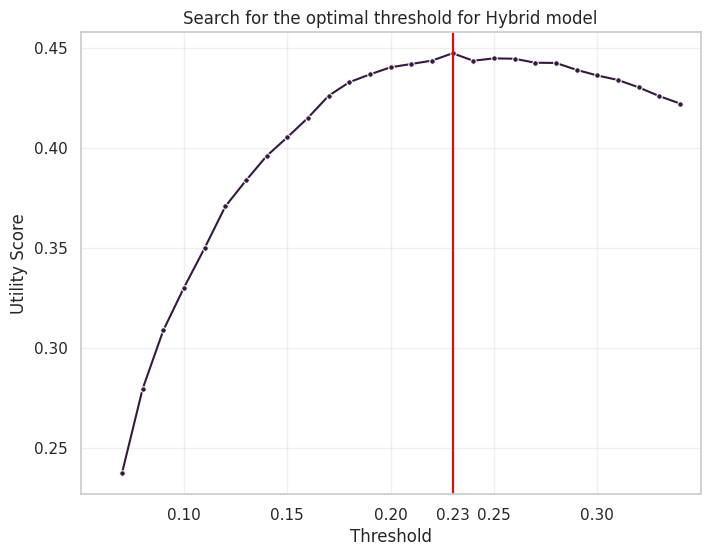

In [62]:
search_thr_graphic(hist_final_originals, "Hybrid model", best_t_final_originals)